<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Estatística Básica - Conceitos e Aplicações**

## **Configurações Iniciais**

In [178]:
# Bibliotecas para manipulação de dados, estatística e gráficos
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [179]:
# Ajustes visuais padrão para manter os gráficos legíveis
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


## **Dataset**

In [180]:
# Leitura do arquivo CSV para o DataFrame principal
df = pd.read_csv('../../dataset/api.csv')
# Primeiras linhas para inspeção inicial dos dados
df.head()


,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
0,1611190130229,Superior,Alameda High,731,693,5,3.45,1278,1090,14,16
1,1611190132878,Superior,Encinal High,622,589,11,3.06,1113,840,20,18
2,1611196000004,Medio,Chipman Middle,622,572,11,2.82,546,472,55,25
3,1611196090005,Fundamental,Lum (Donald D.),774,732,3,3.32,330,272,35,26
4,1611196090013,Fundamental,Edison Elementa,811,784,1,3.76,233,216,15,9


In [181]:
# Estrutura do DataFrame: tipos, nulos e volume de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5423 entries, 0 to 5422
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         5423 non-null   int64  
 1   TIPO       5423 non-null   object 
 2   NOME       5423 non-null   object 
 3   API00      5423 non-null   int64  
 4   API99      5423 non-null   int64  
 5   META       5423 non-null   int64  
 6   EDU        5423 non-null   float64
 7   TEST_INSC  5423 non-null   int64  
 8   TEST_NUM   5423 non-null   int64  
 9   REFS       5423 non-null   int64  
 10  NPI        5423 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 466.2+ KB


## **Medidas de Posição**

Uma **medida de posição** descreve a **localização relativa** de um valor ou de um **ponto de corte** em relação ao conjunto de observações de uma amostra ou população. Diferentemente da média e do desvio padrão, medidas descritivas baseadas em **quantis** tendem a ser **menos sensíveis a valores extremos**. Por esse motivo, medidas baseadas em quantis são frequentemente preferidas quando se deseja uma descrição mais robusta da distribuição dos dados (Weiss, 2010).

Quantis são **pontos de corte** que, em um conjunto de dados **ordenados**, separam as observações em partes com **proporções iguais ou aproximadamente iguais**. Alguns quantis são particularmente importantes: a **mediana** divide o conjunto de dados em duas partes, correspondentes aos 50% inferiores e aos 50% superiores. Os **quartis** dividem os dados em quatro partes, os **decis** em dez partes, os **quintis** em cinco partes e os **percentis** em cem partes. Observe que a mediana corresponde ao **50º percentil**. Em geral, há sempre **um quantil a menos** do que o número de grupos formados.

O cálculo de qualquer medida de posição pode ser expresso em termos da **posição teórica** de um determinado **ponto de corte** no conjunto de dados ordenados.

Dado um conjunto de dados ordenados $x_1, x_2, \ldots, x_n$, a posição $P_j$ da $j$-ésima medida de posição (também chamada de **medida separatriz**) pode ser definida, segundo a **convenção adotada nesta aula**, por

$$
P_j = \frac{j(n+1)}{m},
$$

onde:

- $P_j$ é a posição teórica da $j$-ésima medida separatriz no conjunto ordenado;
- $j$ é a ordem da medida de posição desejada;
- $n$ é o número de observações do conjunto de dados;
- $m$ é o número de partes iguais em que se deseja dividir os dados.

Por exemplo: para quartis, $m=4$; para decis, $m=10$; para percentis, $m=100$.


Se a posição teórica $P_j$ não for inteira, é necessária uma interpolação linear entre os dois valores adjacentes para determinar a medida de posição desejada. Se $P_j$ for inteira, a medida coincide diretamente com o valor observado nessa posição do conjunto ordenado.

A interpolação linear entre dois pontos $(x_0, y_0)$ e $(x_1, y_1)$ pode ser escrita como:

$$
y = y_0 + \frac{y_1-y_0}{x_1-x_0}(x-x_0).
$$

em que $x$ representa a posição fracionária associada à medida de posição, e $y$ corresponde ao valor interpolado da variável de interesse. No contexto das medidas de posição, isso significa que, quando a posição teórica está entre duas observações ordenadas adjacentes, o valor da medida separatriz é estimado proporcionalmente entre esses dois valores, segundo a **convenção adotada nesta aula**.

<p align="center">
  <img src="imgs/interpola_linear.png" height="400px" alt="Esquema de interpolação linear">
</p>

**Fig. 1 - Esquema de interpolação linear entre dois pontos**. A figura ilustra a obtenção de um valor intermediário $y$ a partir da posição $x$ entre os pontos $(x_0, y_0)$ e $(x_1, y_1)$. No contexto das medidas de posição, esse procedimento é usado quando a posição teórica $P_j$ não é inteira, permitindo estimar a medida separatriz entre duas observações adjacentes do conjunto ordenado. Fonte: Carubbi, 2026.

Até aqui, definimos a ideia geral de **medidas de posição** e a forma de localizar uma **posição teórica** no conjunto de dados ordenados. A seguir, aplicaremos essa lógica ao caso particular dos **quartis**, que dividem a amostra em **quatro partes** com a mesma proporção de observações.


### **Quartis e Interquartis**

Os **quartis** são os **três pontos de corte** que dividem um **conjunto de dados ordenados** em **quatro partes** com a mesma proporção de observações, segundo a **convenção adotada nesta aula**. Essas três medidas são denominadas **primeiro quartil** (**$Q_1$**), **segundo quartil** (**$Q_2$**) e **terceiro quartil** (**$Q_3$**). O **segundo quartil** é equivalente à **mediana** do conjunto de dados. Já o **primeiro quartil** e o **terceiro quartil** correspondem, respectivamente, aos pontos abaixo dos quais se encontram aproximadamente **25%** e **75%** das observações ordenadas (Mann, 2012).

<p align="center">
  <img src="imgs/quartiles.png" height="400px" alt="Quartis">
</p>

**Fig. 2 – Representação gráfica dos quartis e da mediana**. A figura ilustra a divisão de um conjunto de dados ordenados em quatro partes iguais por meio de três quartis. O primeiro quartil (Q1) delimita os 25% menores valores, a mediana (M ou Q2) divide o conjunto em duas metades iguais, e o terceiro quartil (Q3) separa os 75% menores dos 25% maiores valores. Cada intervalo entre os quantis contém aproximadamente 25% das observações, evidenciando o uso dos quartis como medidas de posição robustas à presença de valores extremos. Fonte: Adaptado de https://www.sigmamagic.com/blogs/what-are-quartiles/ .

Aproximadamente 25% dos valores em um **conjunto de dados ordenados** são menores que (Q1) e cerca de 75% são maiores que (Q1). O segundo quartil, (Q2), divide um conjunto de dados ordenado em** duas partes iguais**; portanto, o **segundo quartil** e a **mediana são equivalentes**. Aproximadamente 75% dos valores dos dados são menores que (Q3) e cerca de 25% são maiores que (Q3). A **diferença entre o terceiro quartil e o primeiro quartil** de um conjunto de dados é chamada de interquartil (IQR) (Mann, 2012).

Vamos agora testar a funcionalidade do Python para o cálculo de **quantis** e **quartis**. Utilizaremos a variável **`API00`** do conjunto de dados para calcular os quartis e a **amplitude interquartil** (**$IQR$**). A variável **`API00`** corresponde ao índice API observado para cada escola neste conjunto de dados.

Primeiro, selecionaremos a variável **`API00`** e construiremos um **histograma**, a fim de inspecionar com mais detalhe o comportamento de sua distribuição.


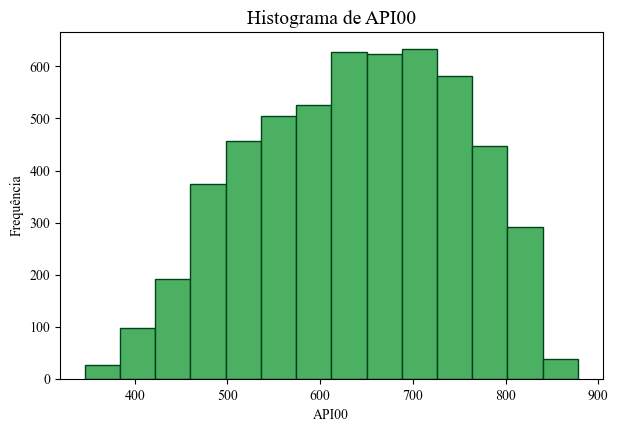

In [182]:
# Seleciona a variável de interesse para a análise de quartis
api00 = df["API00"]

greens = plt.get_cmap("Greens", 6)

# Histograma de API00 para inspecionar a forma da distribuição antes do cálculo dos quartis
fig, ax = plt.subplots()
ax.hist(api00, bins="sturges", color=greens(3), edgecolor=greens(5))
ax.set_title("Histograma de API00")
ax.set_xlabel("API00")
ax.set_ylabel("Frequência")
plt.show()


**Fig. 3 – Histograma de API00**. A figura apresenta a distribuição dos valores da variável **`API00`** por meio de um histograma. Cada barra representa a frequência de escolas em intervalos de valores do índice, permitindo inspecionar a forma geral da distribuição, sua concentração em determinadas faixas e a possível presença de assimetria ou valores extremos. Essa inspeção gráfica auxilia a interpretação posterior dos quartis e da amplitude interquartil. Fonte: Carubbi, 2026.

Para calcular os quartis da variável **`API00`**, aplicaremos a função **`np.percentile()`**. Se consultarmos a documentação para **`np.percentile`**, observaremos que os valores do argumento **`q`** devem ser informados entre **0** e **100**.

Na prática computacional, a biblioteca pode adotar **convenções próprias de interpolação**. Aqui, utilizamos essa função para fins operacionais, mantendo a **convenção teórica adotada nesta aula** como referência conceitual.


In [183]:
# Calcula os quartis de API00 pelos percentis 25, 50 e 75
q1, q2, q3 = np.percentile(api00, [25, 50, 75])

# A amplitude interquartil mede a distância entre o terceiro e o primeiro quartil
iqr = q3 - q1

print(f"Q1 = {q1:.2f}")
print(f"Q2 (mediana) = {q2:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")

Q1 = 552.00
Q2 (mediana) = 645.00
Q3 = 726.00
IQR = 174.00


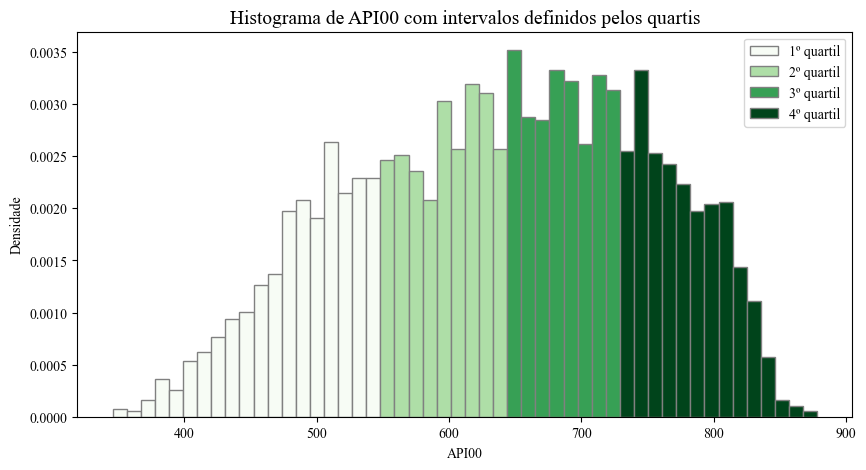

In [184]:
# Limites das quatro faixas definidas pelos quartis de API00
api00_quart = np.percentile(api00, [0, 25, 50, 75, 100])

# Paleta sequencial de verdes para destacar os quatro intervalos definidos pelos quartis
quart_cmap = plt.get_cmap("Greens", 4)

# Histograma em densidade para destacar visualmente as regiões separadas pelos quartis
fig, ax = plt.subplots(figsize=(10, 5))
api00.plot.hist(ax=ax, bins=50, density=True, edgecolor="black")

for bar in ax.containers[0]:
    # Ponto médio da barra para identificar em qual faixa quartílica ela se encontra
    x = bar.get_x() + 0.5 * bar.get_width()

    if x < api00_quart[1]:
        bar.set_color(quart_cmap(0))
        bar.set_edgecolor("grey")
    elif x < api00_quart[2]:
        bar.set_color(quart_cmap(1))
        bar.set_edgecolor("grey")
    elif x < api00_quart[3]:
        bar.set_color(quart_cmap(2))
        bar.set_edgecolor("grey")
    elif x <= api00_quart[4]:
        bar.set_color(quart_cmap(3))
        bar.set_edgecolor("grey")
    else:
        bar.set_color("grey")

ax.set_title("Histograma de API00 com intervalos definidos pelos quartis")
ax.set_ylabel("Densidade")
ax.set_xlabel("API00")

# Legenda com marcadores de cor para as quatro faixas definidas pelos quartis
legend_handles = [
    Patch(facecolor=quart_cmap(0), edgecolor="grey", label="1º quartil"),
    Patch(facecolor=quart_cmap(1), edgecolor="grey", label="2º quartil"),
    Patch(facecolor=quart_cmap(2), edgecolor="grey", label="3º quartil"),
    Patch(facecolor=quart_cmap(3), edgecolor="grey", label="4º quartil"),
]
ax.legend(handles=legend_handles, loc="upper right")
plt.show()

**Fig. 4 – Histograma de API00 com intervalos definidos pelos quartis**. A figura apresenta a distribuição da variável **`API00`** em escala de densidade, com as barras coloridas de acordo com os quatro intervalos determinados por **$Q_1$**, **$Q_2$** e **$Q_3$**. Essa representação permite visualizar como os valores do índice se distribuem entre os segmentos delimitados pelos quartis, facilitando a interpretação conjunta da forma da distribuição e da posição relativa das observações. Fonte: Carubbi, 2026.

## **Valores Atípicos (Outliers)**

Com os **quartis** e a **amplitude interquartil** em mãos, podemos avançar da descrição da posição e da dispersão para uma aplicação diagnóstica importante: a identificação de **valores atípicos** por meio da **cerca de Tukey**, em homenagem ao matemático **John Wilder Tukey**.


Na **análise de dados**, a identificação de **outliers** (**valores atípicos**), isto é, observações que se afastam significativamente do **padrão geral dos dados**, é muito importante. Um **outlier** requer **atenção especial**. Ele pode ser resultado de um **erro de medição** ou de **registro**, uma observação proveniente de uma **população diferente** ou uma **observação extrema incomum**. Observe que uma **observação extrema** não precisa necessariamente ser um **outlier**; ela pode, em vez disso, ser uma indicação de **assimetria da distribuição** (Weiss, 2010).

Ao observar um **outlier**, deve-se tentar determinar sua **causa**. Se o **outlier** for causado por um **erro de medição** ou de **registro**, ou se por algum outro motivo estiver claro que ele **não pertence ao conjunto de dados**, o **outlier** pode simplesmente ser **removido**. No entanto, se não houver uma **explicação evidente** para o **outlier**, a decisão de **mantê-lo** ou não no conjunto de dados constitui um **julgamento difícil**.

Tradicionalmente, a **cerca de Tukey** é utilizada como uma **ferramenta diagnóstica** para a identificação de observações que podem ser consideradas **outliers**, baseando-se exclusivamente nos **quartis** e no **intervalo interquartil** (**$IQR$**). Para isso, definem-se o **limite inferior** e o **limite superior** de um conjunto de dados. O **limite inferior** é o valor que se encontra **1,5 vezes o $IQR$ abaixo do primeiro quartil**; o **limite superior** é o valor que se encontra **1,5 vezes o $IQR$ acima do terceiro quartil**. Observações que estejam **abaixo do limite inferior** ou **acima do limite superior** são consideradas **potenciais outliers** (Weiss, 2010).

Sejam **$Q_1$** o **primeiro quartil**, **$Q_3$** o **terceiro quartil** e **$IQR = Q_3 - Q_1$**. O **limite inferior** **$L$** é definido como:

$$
L = Q_1 - 1.5\,IQR
$$

e o **limite superior** **$U$** é definido como

$$
U = Q_3 + 1.5\,IQR
$$

Um **boxplot**, também chamado de **diagrama de caixa e bigodes**, baseia-se no **resumo de cinco números** e pode ser utilizado para fornecer uma **representação gráfica** da **posição central** e da **variabilidade** de um conjunto de dados. Esses diagramas foram introduzidos pelo matemático **John Wilder Tukey**. Diversos tipos de **boxplots** são comumente utilizados.

Os **diagramas de caixa e bigodes** fornecem uma **representação gráfica dos dados** utilizando **cinco medidas**: a **mediana**, o **primeiro quartil**, o **terceiro quartil**, bem como o **menor** e o **maior valor** situados entre os **limites inferior e superior** do conjunto de dados. O **espaçamento** entre as diferentes partes da caixa indica o grau de **dispersão** e de **assimetria** dos dados. É possível **comparar diferentes distribuições** construindo **boxplots** para cada uma delas, além de facilitar a **identificação de outliers** (Mann, 2012). Os **boxplots** podem ser construídos tanto na **orientação horizontal** quanto **vertical**.


In [185]:
# Outliers de API00 identificados pela cerca de Tukey
q1_api00, q3_api00 = np.percentile(df["API00"].dropna(), [25, 75])
iqr_api00 = q3_api00 - q1_api00
limite_inferior_api00 = q1_api00 - 1.5 * iqr_api00
limite_superior_api00 = q3_api00 + 1.5 * iqr_api00
print(f"Limite inferior para outliers de API00: {limite_inferior_api00:.2f}")
print(f"Limite superior para outliers de API00: {limite_superior_api00:.2f}")

Limite inferior para outliers de API00: 291.00
Limite superior para outliers de API00: 987.00


In [186]:
# Condição para identificar os outliers de API00 com base nos limites calculados
cond_outliers_api00 = (df["API00"] < limite_inferior_api00) | (df["API00"] > limite_superior_api00)
api00_outliers = df.loc[cond_outliers_api00,].sort_values("API00")

api00_outliers

,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI


In [187]:
# Outliers de TEST_NUM identificados pela cerca de Tukey
q1_test_num, q3_test_num = np.percentile(df["TEST_NUM"].dropna(), [25, 75])
iqr_test_num = q3_test_num - q1_test_num
limite_inferior_test_num = q1_test_num - 1.5 * iqr_test_num
limite_superior_test_num = q3_test_num + 1.5 * iqr_test_num
print(f"Limite inferior para outliers de TEST_NUM: {limite_inferior_test_num:.2f}")
print(f"Limite superior para outliers de TEST_NUM: {limite_superior_test_num:.2f}")

Limite inferior para outliers de TEST_NUM: -214.00
Limite superior para outliers de TEST_NUM: 1106.00


In [188]:
# Condição para identificar os outliers de TEST_NUM com base nos limites calculados
cond_outliers_test_num = (df["TEST_NUM"] < limite_inferior_test_num) | (df["TEST_NUM"] > limite_superior_test_num)
test_num_outliers = df.loc[cond_outliers_test_num,].sort_values("TEST_NUM")

test_num_outliers.sort_values("TEST_NUM", ascending=False)

,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
1816,19647336058309,Medio,South Gate Midd,488,480,16,2.04,4117,3862,93,29
1832,19647336061469,Medio,Gage (Henry T.),446,435,18,1.81,3342,3199,85,36
1262,19647251935758,Superior,Millikan Senior,595,586,11,2.71,3337,3126,35,24
1372,19647331937424,Superior,Roosevelt (Theo,463,461,17,1.55,3560,3103,86,36
1783,19647336057939,Medio,Nimitz (Chester,441,419,19,1.98,3321,3094,90,37
...,...,...,...,...,...,...,...,...,...,...,...
333,7617540731380,Superior,Clayton Valley,720,706,5,3.53,1315,1113,8,3
4121,38684783830254,Superior,Burton (Phillip,599,574,11,2.68,1313,1111,21,18
1340,19647331931476,Superior,Canoga Park Sen,546,506,15,2.20,1499,1111,76,29
314,7616486061154,Medio,Park Middle,699,658,7,2.98,1391,1108,24,1


In [189]:
# Função para gerar boxplot e histograma com curva KDE para uma variável numérica
def plot_box_hist_kde(series, x_label, title, cmap_index=3):
    greens = plt.get_cmap("Greens", 6)
    box_color = greens(cmap_index)
    line_color = greens(5)
    data = series.dropna()

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), gridspec_kw={"height_ratios": [1, 1.4]})
    ax_box, ax_hist = axes

    # Boxplot horizontal para destacar mediana, quartis e possíveis outliers
    ax_box.boxplot(
        data,
        vert=False,
        widths=0.45,
        patch_artist=True,
        boxprops={"facecolor": box_color, "edgecolor": line_color, "linewidth": 1.5},
        medianprops={"color": "#111111", "linewidth": 2},
        whiskerprops={"color": line_color, "linestyle": "--", "linewidth": 1.3},
        capprops={"color": line_color, "linewidth": 1.3},
        flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": line_color, "markersize": 4},
    )

    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    media = data.mean()
    for x, label in [(q1, "Q1"), (q2, "Q2"), (q3, "Q3")]:
        ax_box.text(x, 1.28, label, ha="center", va="bottom", fontsize=11)

    ax_box.set_title(title, fontsize=13)
    ax_box.set_yticks([])
    ax_box.spines[["left", "right", "top"]].set_visible(False)
    ax_box.grid(axis="x", alpha=0.15)

    # Histograma com curva KDE para visualizar a forma da distribuição
    ax_hist.hist(data, bins=35, density=True, color=box_color, edgecolor=line_color, alpha=0.75, label="Histograma")
    x_grid = np.linspace(data.min(), data.max(), 400)
    kde = stats.gaussian_kde(data)
    ax_hist.plot(x_grid, kde(x_grid), color=line_color, linewidth=2, label="Curva KDE")
    ax_hist.axvline(media, color="#1f1f1f", linestyle=":", linewidth=1.8, label="Média")
    ax_hist.set_ylabel("Densidade")
    ax_hist.set_xlabel(x_label)
    ax_hist.spines[["top", "right"]].set_visible(False)
    ax_hist.grid(axis="y", alpha=0.15)
    ax_hist.legend(loc="upper right")

    fig.tight_layout()
    plt.show()


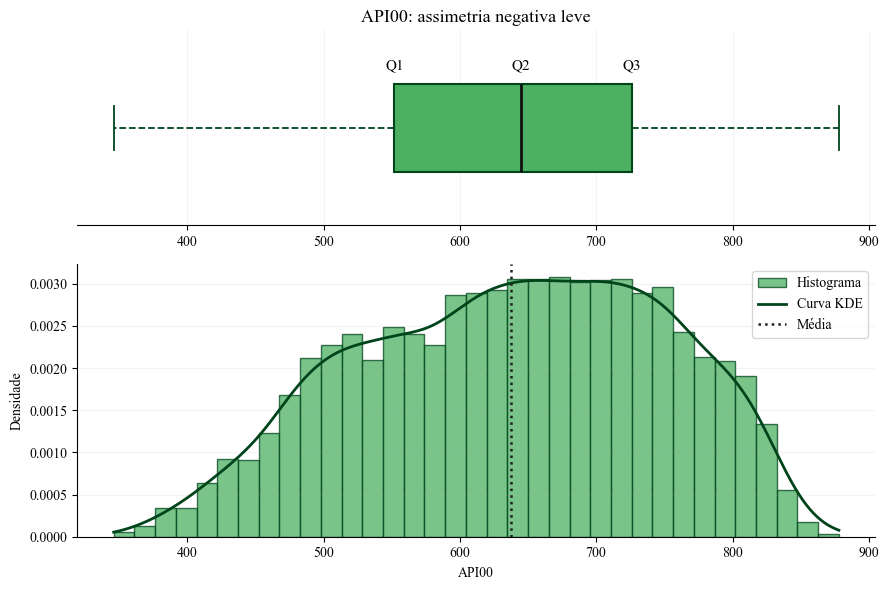

In [190]:
# Aplicação da função para API00
plot_box_hist_kde(df["API00"], "API00", "API00: assimetria negativa leve", cmap_index=3)


**Fig. 5 – Boxplot e histograma em densidade de `API00`**. A figura apresenta o **boxplot** e o **histograma com curva KDE** da variável **`API00`**. O boxplot resume a posição da **mediana**, dos **quartis** e de possíveis **outliers**, enquanto o histograma em densidade, complementado pela **curva KDE**, permite visualizar a forma da distribuição e sua **assimetria negativa leve**. Em distribuições com **assimetria negativa**, a **média** tende a ficar **à esquerda da mediana**, pois a cauda mais longa se estende em direção aos menores valores. Fonte: Carubbi, 2026.

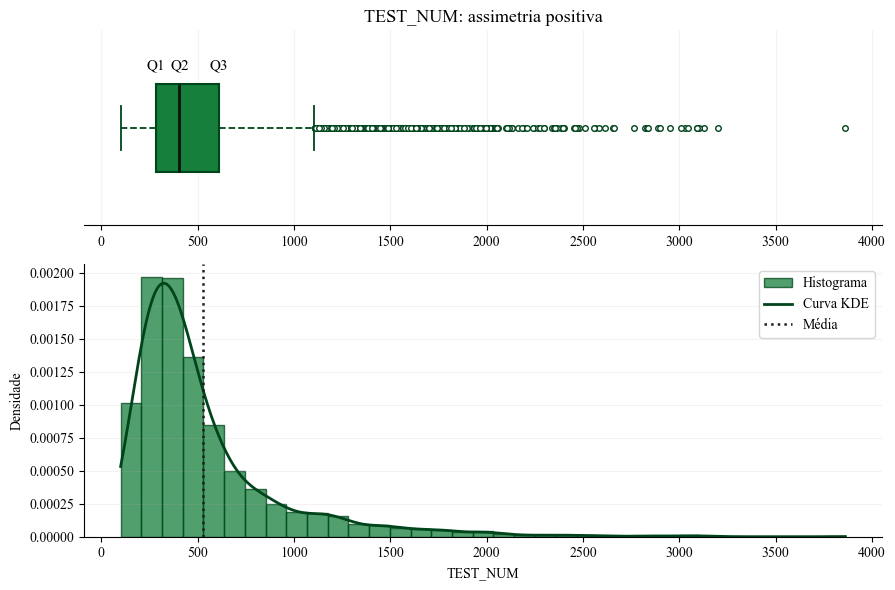

In [191]:
# Aplicação da função para TEST_NUM
plot_box_hist_kde(df["TEST_NUM"], "TEST_NUM", "TEST_NUM: assimetria positiva", cmap_index=4)


**Fig. 6 – Boxplot e histograma em densidade de `TEST_NUM`**. A figura apresenta o **boxplot** e o **histograma com curva KDE** da variável **`TEST_NUM`**. Nesse caso, observa-se uma **assimetria positiva** mais acentuada, perceptível tanto pela extensão da cauda à direita quanto pela posição relativa da mediana e dos quartis no boxplot. Em distribuições com **assimetria positiva**, a **média** tende a ficar **à direita da mediana**, acompanhando a cauda mais longa em direção aos maiores valores. Fonte: Carubbi, 2026.

## **Sumário de Cinco Números**

A partir dos **três quartis** (**$Q_1$**, **$Q_2$**, **$Q_3$**), podemos obter uma **medida de posição central** — a **mediana**, dada por **$Q_2$** — e medidas de **variação** dos dois quartos centrais dos dados: **$Q_2 - Q_1$** para o **segundo quarto** e **$Q_3 - Q_2$** para o **terceiro quarto**. No entanto, os três quartis, sozinhos, não informam nada sobre a variação do **primeiro** e do **último quartos** da distribuição.

Para obter essa informação, incluímos também a **observação mínima** e a **observação máxima**. A variação do **primeiro quarto** pode ser medida pela diferença entre o **primeiro quartil** e o **mínimo**, isto é, **$Q_1 - Min$**. A variação do **último quarto** pode ser medida pela diferença entre o **máximo** e o **terceiro quartil**, isto é, **$Max - Q_3$**. Assim, **mínimo**, **máximo** e **quartis**, em conjunto, fornecem informações importantes sobre a **posição central** e a **variação** dos dados (Weiss, 2010).

O chamado **Sumário de Cinco Números de Tukey** (*Tukey Five-Number Summary*), em homenagem ao matemático **John Wilder Tukey**, é composto por **$Min$**, **$Q_1$**, **$Q_2$**, **$Q_3$** e **$Max$** de um conjunto de dados.

No Python, a função **`describe()`** já fornece o **sumário de cinco números** — **`min`**, **`25%`**, **`50%`**, **`75%`** e **`max`** — além de outras estatísticas descritivas, como **`count`**, **`mean`** e **`std`**. Ainda assim, pode ser útil definir uma função específica quando se deseja exibir apenas esses **cinco valores** de forma mais direta. A seguir, definimos uma função simples para obter o **Sumário de Cinco Números** e a aplicamos à variável **`API00`** deste conjunto de dados.


In [192]:
# Função para calcular o Sumário de Cinco Números de Tukey
def five_number_summary(series):
    data = series.dropna()
    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    return pd.DataFrame({
        "Estatística": ["Min", "Q1", "Q2", "Q3", "Max"],
        "Valor": [data.min(), q1, q2, q3, data.max()],
    })

five_number_summary(df["API00"])


,Estatística,Valor
0,Min,346.0
1,Q1,552.0
2,Q2,645.0
3,Q3,726.0
4,Max,878.0


Os **quartis** e o **intervalo interquartil** descrevem bem a parte central da distribuição, mas não resumem sozinhos toda a extensão dos dados. Para obter uma visão mais completa da posição e da variação, consideramos também os valores **mínimo** e **máximo**, formando o **sumário de cinco números**.


In [193]:
# Descrição estatística detalhada de API00 para complementar o sumário de cinco números
df['API00'].describe()

count    5423.000000
mean      637.561129
std       110.662573
min       346.000000
25%       552.000000
50%       645.000000
75%       726.000000
max       878.000000
Name: API00, dtype: float64

Os **quartis** representam um caso particular importante das medidas separatrizes. Agora, ampliaremos essa ideia para os **percentis**, que dividem o conjunto de dados ordenados em **100 partes**, permitindo uma descrição mais fina da posição relativa das observações.


## **Percentis e Posição na Amostra Ordenada**

Os **percentis** dividem um **conjunto de dados ordenados** em **100 partes iguais**. Cada conjunto de dados possui **99 percentis**, que o separam em **100 partes**. O **$k$-ésimo percentil** é denotado por **$P_k$**, em que **$k$** é um inteiro entre **1** e **99**. Por exemplo, o **25º percentil** é denotado por **$P_{25}$**.

Assim, o **$k$-ésimo percentil**, **$P_k$**, pode ser definido como um valor do conjunto de dados tal que aproximadamente **$k\%$** das observações são **menores** que **$P_k$** e aproximadamente **$(100-k)\%$** das observações são **maiores** que **$P_k$**.

De acordo com a **convenção adotada nesta aula**, a **posição teórica** do **$k$-ésimo percentil** na **amostra ordenada** pode ser expressa por

$$
P_k = \frac{k(n+1)}{100},
$$

em que **$k$** representa o número do percentil e **$n$** representa o **tamanho da amostra**. Observe que essa expressão fornece a **posição teórica** do percentil na amostra ordenada; o valor do percentil é então obtido a partir da observação correspondente ou por **interpolação**, conforme a convenção adotada.

Como exercício, calcularemos em Python o **38º**, o **50º** e o **73º percentis** da variável **`API00`** do conjunto de dados. Em um primeiro passo, calcularemos a posição do **38º percentil** de acordo com a expressão apresentada acima.


In [194]:
# Cálculo dos percentis 38, 50 e 73 de API00
api00 = df["API00"].dropna().sort_values().reset_index(drop=True)
n = len(api00)
ks = np.array([38, 50, 73])

# Posições teóricas segundo a convenção adotada nesta aula
posicoes = ks * (n + 1) / 100

# Valores dos percentis obtidos com interpolação linear
percentis = np.percentile(api00, ks)

pd.DataFrame({
    "Percentil": [f"P{k}" for k in ks],
    "Posição teórica": posicoes,
    "Valor em API00": percentis,
})


,Percentil,Posição teórica,Valor em API00
0,P38,2061.12,603.0
1,P50,2712.00,645.0
2,P73,3959.52,719.0


In [199]:
# Valores adjacentes de API00 usados na localização dos percentis pela convenção da aula
api00_ordenado = df["API00"].dropna().sort_values().reset_index(drop=True)

for k, pos in zip(ks, posicoes):
    if float(pos).is_integer():
        indice = int(pos) - 1
        print(f"P{k}: posição inteira {int(pos)} -> iloc[{indice}] = {api00_ordenado.iloc[indice]}")
    else:
        inferior = int(np.floor(pos))
        superior = int(np.ceil(pos))
        frac = pos - inferior
        print(f"P{k}: posição {pos:.2f} -> entre iloc[{inferior-1}] e iloc[{superior-1}]")
        print(f"  valores adjacentes: {api00_ordenado.iloc[inferior-1]} e {api00_ordenado.iloc[superior-1]}")
        print(f"  fração interpolada: {frac:.2f}")


P38: posição 2061.12 -> entre iloc[2060] e iloc[2061]
  valores adjacentes: 603 e 603
  fração interpolada: 0.12
P50: posição inteira 2712 -> iloc[2711] = 645
P73: posição 3959.52 -> entre iloc[3958] e iloc[3959]
  valores adjacentes: 719 e 719
  fração interpolada: 0.52


Até aqui, trabalhamos com o **valor do percentil** e com sua **posição teórica** na amostra ordenada. A seguir, introduziremos uma noção diferente, mas relacionada: o **posto percentílico**, que indica a porcentagem de observações abaixo de um valor específico.


### **Posto Percentílico**

Podemos verificar, por exemplo, se a **mediana** da variável **`API00`** corresponde ao **50º percentil** calculado acima.

Também podemos calcular o **posto percentílico** (*percentile rank*) de um valor particular **$x_i$** de um conjunto de dados pela seguinte expressão:

$$
PR(x_i) = \frac{\text{número de valores menores que } x_i}{\text{número total de valores no conjunto de dados}} \times 100
$$

O **posto percentílico** de **$x_i$** fornece a **porcentagem de valores** do conjunto de dados que são **menores** que **$x_i$**.

Em Python, a função **`scipy.stats.percentileofscore()`** pode ser usada para calcular o **posto percentílico** de um valor em relação a uma lista de observações. Como a fórmula acima considera estritamente o **número de valores menores que** **$x_i$**, utilizaremos a opção **`kind="strict"`** para manter consistência com essa definição.

A seguir, calcularemos, por exemplo, o **posto percentílico** correspondente a **`API00 = 650`**.


In [195]:
# Cálculo do posto percentílico de API00 = 650
valor_api00 = 650
posto_percentil = stats.percentileofscore(df["API00"].dropna(), valor_api00, kind="strict")

pd.DataFrame({
    "Valor de API00": [valor_api00],
    "Posto percentílico (%)": [f"{posto_percentil:.2f}"],
})


,Valor de API00,Posto percentílico (%)
0,650,51.72


Arredondando o resultado para o **inteiro mais próximo**, podemos afirmar que aproximadamente **52%** das escolas do conjunto de dados apresentam um valor de **`API00`** **inferior a 650**.


Nesta seção, vimos que **quartis** e **percentis** descrevem a **posição** das observações na distribuição, enquanto o **$IQR$** resume a **dispersão central** dos dados. Com base nessas medidas, a **cerca de Tukey** apoia a identificação diagnóstica de **valores atípicos**, e os **boxplots** e **histogramas** ajudam a visualizar, de forma complementar, aspectos de **posição**, **variabilidade**, **assimetria** e **outliers**.


## **Citação**

Estas aulas são baseadas no projeto de e-learning [SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/index.html) que foi desenvolvido no Departamento de Ciências da Terra por Annette Rudolph, Joachim Krois e Kai Hartmann. O contato pode ser realizado por e-mail, pelo endereço [soga[at]zedat.fu-berlin.de](soga[at]zedat.fu-berlin.de).

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Attribution-ShareAlike 4.0 International. 

Por favor, cite da seguinte forma: Rudolph, A., Krois, J., Hartmann, K. (2023): Estatística e Análise de Geodados usando Python (SOGA-Py). Departamento de Ciências da Terra, Universidade Livre de Berlim.